In [17]:
# Install requirements first if you haven't:
# !pip install opencv-python torch transformers pillow sentence-transformers faiss-cpu matplotlib

import cv2
from sentence_transformers import SentenceTransformer
from PIL import Image
import faiss
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
VIDEO_PATH = "my_cctv_footage.mp4" # Make sure this file is in the same folder!

# --- STEP 1: LOAD MODEL ---
print("Loading AI Brain (CLIP)...")
model = SentenceTransformer('clip-ViT-B-32')

# --- STEP 2: PROCESS VIDEO ---
print(f"Scanning {VIDEO_PATH}...")
cap = cv2.VideoCapture(VIDEO_PATH)
images = []
timestamps = []
frame_rate = cap.get(cv2.CAP_PROP_FPS)
current_frame = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # Capture 1 frame every second (Adjust '1' to '2' to skip more frames)
    if current_frame % int(frame_rate) == 0:
        # Convert BGR (OpenCV) to RGB (Normal)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        
        images.append(pil_image)
        timestamps.append(current_frame / frame_rate)
        
    current_frame += 1
cap.release()

print(f"✅ Extracted {len(images)} frames from video.")

# --- STEP 3: CREATE EMBEDDINGS ---
print("converting images to math (Vectors)...")
image_embeddings = model.encode(images, show_progress_bar=False)

# --- STEP 4: BUILD SEARCH ENGINE ---
dimension = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(image_embeddings) # Normalize for cosine similarity
index.add(image_embeddings)
print("✅ Index Built!")

# --- STEP 5: THE SEARCH FUNCTION ---
def search(query, top_k=3):
    # 1. Convert text to vector
    text_vector = model.encode([query])
    faiss.normalize_L2(text_vector)
    
    # 2. Search index
    distances, indices = index.search(text_vector, top_k)
    
    # 3. Display Results
    print(f"\nResults for: '{query}'")
    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(indices[0]):
        score = distances[0][i]
        timestamp = timestamps[idx]
        
        # Plot
        ax = plt.subplot(1, top_k, i + 1)
        ax.imshow(images[idx])
        ax.set_title(f"{int(timestamp//60)}:{int(timestamp%60)} (Conf: {score:.2f})")
        ax.axis("off")
    plt.show()

Loading AI Brain (CLIP)...
Scanning my_cctv_footage.mp4...
✅ Extracted 36 frames from video.
converting images to math (Vectors)...
✅ Index Built!



Results for: 'red car'


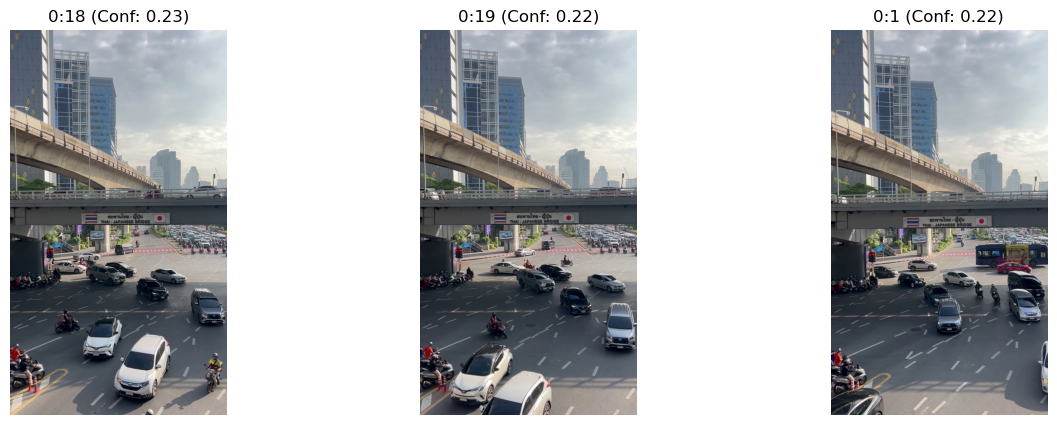

In [19]:
search("red car")


Results for: 'pink taxi'


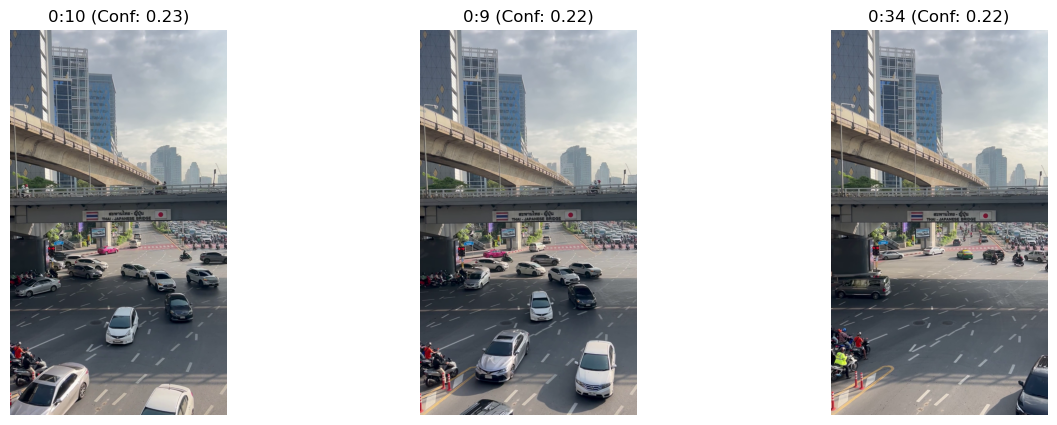

In [21]:
search("pink taxi")
